# Import Library

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os
import time

IMG_SIZE_CD = (128, 128)
BATCH_SIZE = 32
PATH_TRAIN_CD = "../dataset/train"
PATH_TEST_CD  = "../dataset/test"

# Load Dataset cats and dogs

In [41]:
train_cd_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_TRAIN_CD, validation_split=0.3, subset="training", seed=123,
    image_size=IMG_SIZE_CD, batch_size=BATCH_SIZE
)

val_cd_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_TRAIN_CD, validation_split=0.3, subset="validation", seed=123,
    image_size=IMG_SIZE_CD, batch_size=BATCH_SIZE
)

test_cd_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_TEST_CD, image_size=IMG_SIZE_CD, batch_size=BATCH_SIZE, shuffle=False
)

class_names_cd = train_cd_ds.class_names
print("Kelas Cats vs Dogs:", class_names_cd)

Found 557 files belonging to 2 classes.
Using 390 files for training.
Found 557 files belonging to 2 classes.
Using 167 files for validation.
Found 140 files belonging to 2 classes.
Kelas Cats vs Dogs: ['cats', 'dogs']


# Load Dataset CIFAR-10

In [42]:
print("--- Memuat Dataset CIFAR-10 (CNN From Scratch) ---")

(x_train_cf, y_train_cf), (x_test_cf, y_test_cf) = tf.keras.datasets.cifar10.load_data()

x_train_cf, x_test_cf = x_train_cf / 255.0, x_test_cf / 255.0

val_size = int(len(x_train_cf) * 0.15)
x_val_cf, y_val_cf = x_train_cf[:val_size], y_train_cf[:val_size]
x_train_cf, y_train_cf = x_train_cf[val_size:], y_train_cf[val_size:]

print(f"CIFAR-10 Train shape: {x_train_cf.shape}")
print(f"CIFAR-10 Val shape: {x_val_cf.shape}")
print(f"CIFAR-10 Test shape: {x_test_cf.shape}")

class_names_cf = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

--- Memuat Dataset CIFAR-10 (CNN From Scratch) ---
CIFAR-10 Train shape: (42500, 32, 32, 3)
CIFAR-10 Val shape: (7500, 32, 32, 3)
CIFAR-10 Test shape: (10000, 32, 32, 3)


# Data Augmentation

In [43]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# EXPERIMENT 1

In [44]:
model_scratch = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_scratch.compile(optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

model_scratch.summary()

print("\n--- Memulai Training CNN Scratch (CIFAR-10) ---")
start_scratch = time.time()
history_scratch = model_scratch.fit(x_train_cf, y_train_cf, validation_data=(x_val_cf, y_val_cf), epochs=10, batch_size=64)
waktu_scratch = time.time() - start_scratch
print(f"Selesai! Waktu Training: {waktu_scratch:.2f} detik")

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


--- Memulai Training CNN Scratch (CIFAR-10) ---
Epoch 1/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.3682 - loss: 1.7153 - val_accuracy: 0.4959 - val_loss: 1.4277
Epoch 2/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.5137 - loss: 1.3641 - val_accuracy: 0.5692 - val_loss: 1.1958
Epoch 3/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.5758 - loss: 1.2091 - val_accuracy: 0.6296 - val_loss: 1.0611
Epoch 4/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.6143 - loss: 1.0985 - val_accuracy: 0.5935 - val_loss: 1.2143
Epoch 5/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.6407 - loss: 1.0230 - val_accuracy: 0.6539 - val_loss: 0.9817
Epoch 6/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.6637 - loss: 0.9634 - val_accuracy: 0.6764 - val_loss: 0.9177
Epoch 7/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 44s 64ms/step - accuracy: 0.6799 - loss: 0.9140 - val_accuracy: 0.6832 - val_loss: 0.8931
Epoch 8/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 6

# EXPERIMENT 2

In [48]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Feature Extraction: Membekukan basis model [cite: 65, 66]

model_tl = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Klasifikasi biner (Cats vs Dogs)
])

model_tl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tl.summary()

start_tl = time.time()
history_tl = model_tl.fit(train_cd_ds, validation_data=val_cd_ds, epochs=5)
waktu_tl = time.time() - start_tl
print(f"Selesai! Waktu Training: {waktu_tl:.2f} detik")

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_14 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 897ms/step - accuracy: 0.6872 - loss: 0.6189 - val_accuracy: 0.8982 - val_loss: 0.2547
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 430ms/step - accuracy: 0.8641 - loss: 0.3299 - val_accuracy: 0.9222 - val_loss: 0.1946
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - accuracy: 0.8949 - loss: 0.2371 - val_accuracy: 0.9042 - val_loss: 0.2149
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.8974 - loss: 0.2224 - val_accuracy: 0.9281 - val_loss: 0.1832
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/step - accuracy: 0.9282 - loss: 0.1799 - val_accuracy: 0.9162 - val_loss: 0.1786
Selesai! Waktu Training: 42.25 detik


# Build Graphic Perform Model

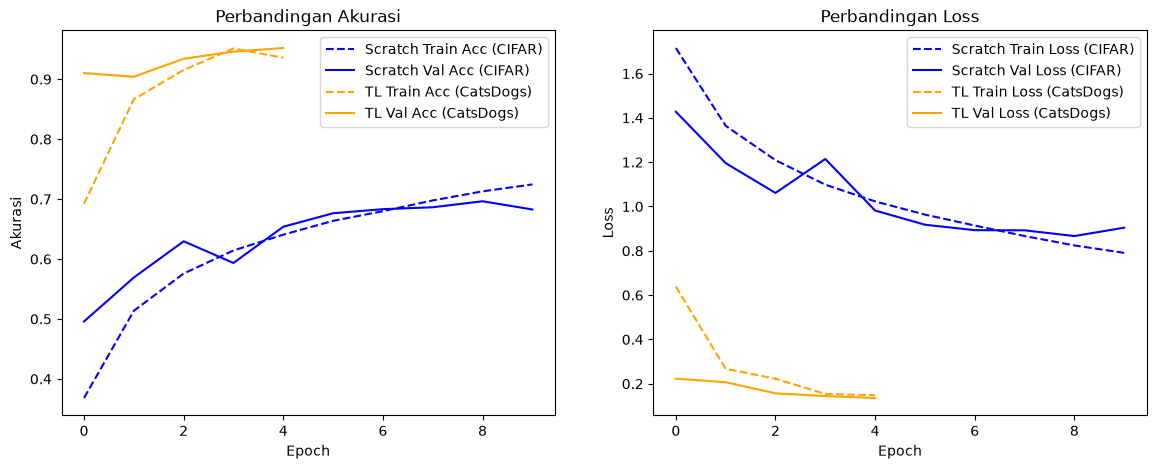

In [46]:
plt.figure(figsize=(14, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Scratch Train Acc (CIFAR)', color='blue', linestyle='--')
plt.plot(history_scratch.history['val_accuracy'], label='Scratch Val Acc (CIFAR)', color='blue')
plt.plot(history_tl.history['accuracy'], label='TL Train Acc (CatsDogs)', color='orange', linestyle='--')
plt.plot(history_tl.history['val_accuracy'], label='TL Val Acc (CatsDogs)', color='orange')
plt.title('Perbandingan Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['loss'], label='Scratch Train Loss (CIFAR)', color='blue', linestyle='--')
plt.plot(history_scratch.history['val_loss'], label='Scratch Val Loss (CIFAR)', color='blue')
plt.plot(history_tl.history['loss'], label='TL Train Loss (CatsDogs)', color='orange', linestyle='--')
plt.plot(history_tl.history['val_loss'], label='TL Val Loss (CatsDogs)', color='orange')
plt.title('Perbandingan Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating And Testing

In [47]:
print("Mengevaluasi Data Testing Akhir")

# Evaluasi CIFAR-10
loss_s, acc_s = model_scratch.evaluate(x_test_cf, y_test_cf, verbose=0)
pred_scratch_prob = model_scratch.predict(x_test_cf)
pred_scratch = np.argmax(pred_scratch_prob, axis=1)

# Evaluasi cats vs dogs
loss_t, acc_t = model_tl.evaluate(test_cd_ds, verbose=0)
y_true_cd = np.concatenate([y for x, y in test_cd_ds], axis=0)
pred_tl = (model_tl.predict(test_cd_ds) > 0.5).astype("int32").flatten()

print("\n=================================================================")
print("                  TABEL RINGKASAN HASIL AKHIR                    ")
print("=================================================================")
print(f"CNN Scratch (CIFAR-10)   -> Akurasi Test: {acc_s*100:.2f}% | Waktu: {waktu_scratch:.2f}s")
print(f"Transfer Learning (C&D)  -> Akurasi Test: {acc_t*100:.2f}% | Waktu: {waktu_tl:.2f}s")
print("=================================================================")

print("\n[CONFUSION MATRIX - CNN SCRATCH (CIFAR-10)]")
print(confusion_matrix(y_test_cf, pred_scratch))

print("\n[CONFUSION MATRIX - TRANSFER LEARNING (CATS VS DOGS)]")
print(confusion_matrix(y_true_cd, pred_tl))

Mengevaluasi Data Testing Akhir
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step  

                  TABEL RINGKASAN HASIL AKHIR                    
CNN Scratch (CIFAR-10)   -> Akurasi Test: 67.86% | Waktu: 331.19s
Transfer Learning (C&D)  -> Akurasi Test: 88.57% | Waktu: 55.89s

[CONFUSION MATRIX - CNN SCRATCH (CIFAR-10)]
[[598  10 126  43  35  26  10  22  78  52]
 [ 17 692  11  23   7  13  19   7  32 179]
 [ 36   3 529  77  85 142  93  21   4  10]
 [  6   2  49 464  42 321  60  30   4  22]
 [ 11   1  67  86 592  92  83  57   7   4]
 [  4   0  26 126  27 751  24  32   2   8]
 [  2   1  36  83  12  48 807   3   3   5]
 [  4   0  29  38  68 126   4 714   1  16]
 [ 39  15  23  40  11  19  10   8 792  43]
 [ 14  32  10  31   3  15  13  13  22 847]]

[CONFUSION MATRIX - TRANSFER LEARNING (CATS VS DOGS)]
[[55 15]
 [ 1 69]]


# Prediksi Benar dan Salah

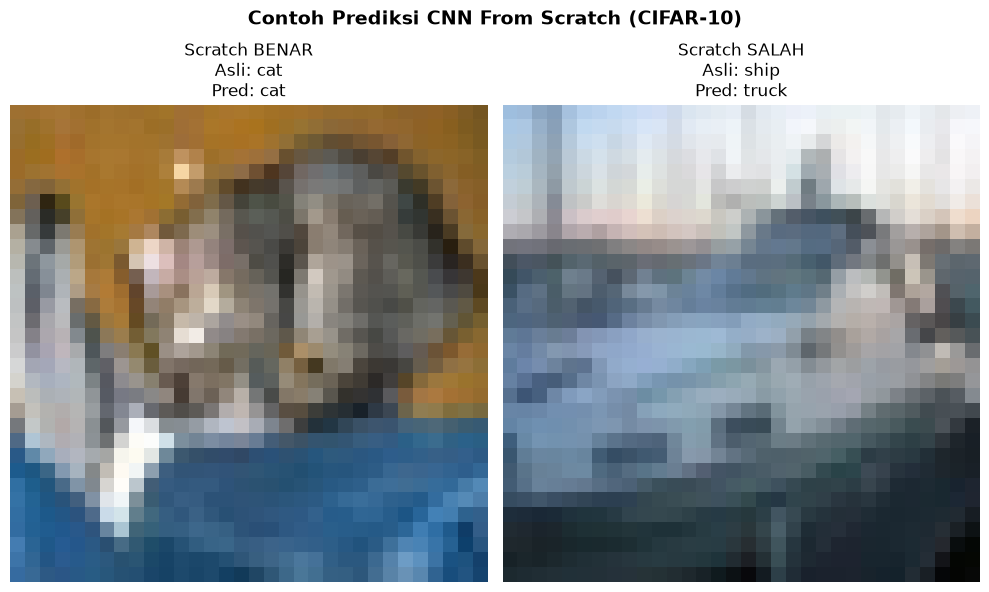

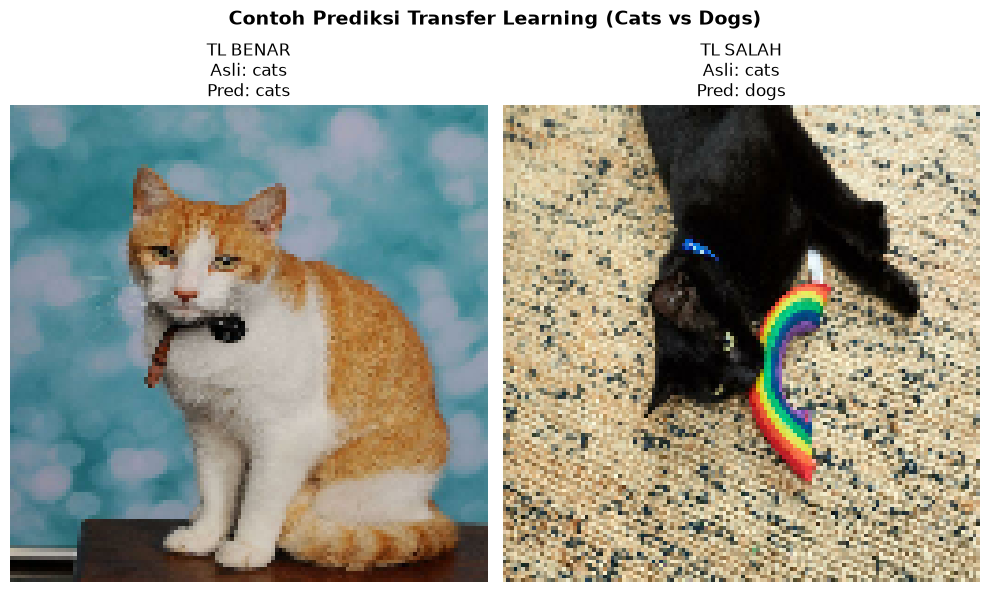

In [51]:
plt.figure(figsize=(10, 6)) 
idx_correct_s = np.where(pred_scratch == y_test_cf.flatten())[0][0]
idx_wrong_s = np.where(pred_scratch != y_test_cf.flatten())[0][0]

plt.subplot(1, 2, 1)
plt.imshow(x_test_cf[idx_correct_s])
plt.title(f"Scratch BENAR\nAsli: {class_names_cf[y_test_cf[idx_correct_s][0]]}\nPred: {class_names_cf[pred_scratch[idx_correct_s]]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_test_cf[idx_wrong_s])
plt.title(f"Scratch SALAH\nAsli: {class_names_cf[y_test_cf[idx_wrong_s][0]]}\nPred: {class_names_cf[pred_scratch[idx_wrong_s]]}")
plt.axis('off')

plt.suptitle("Contoh Prediksi CNN From Scratch (CIFAR-10)", fontsize=14, weight='bold', y=1.02)
plt.tight_layout() 
plt.show()

images_cd, labels_cd = next(iter(test_cd_ds))
images_cd = images_cd.numpy() / 255.0  
labels_cd = labels_cd.numpy()
pred_tl_batch = pred_tl[:len(labels_cd)]

plt.figure(figsize=(10, 6))
idx_correct_t = np.where(pred_tl_batch == labels_cd)[0][0]
idx_wrong_t = np.where(pred_tl_batch != labels_cd)[0][0]

plt.subplot(1, 2, 1)
plt.imshow(images_cd[idx_correct_t])
plt.title(f"TL BENAR\nAsli: {class_names_cd[int(labels_cd[idx_correct_t])]}\nPred: {class_names_cd[int(pred_tl_batch[idx_correct_t])]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(images_cd[idx_wrong_t])
plt.title(f"TL SALAH\nAsli: {class_names_cd[int(labels_cd[idx_wrong_t])]}\nPred: {class_names_cd[int(pred_tl_batch[idx_wrong_t])]}")
plt.axis('off')

plt.suptitle("Contoh Prediksi Transfer Learning (Cats vs Dogs)", fontsize=14, weight='bold', y=1.02)
plt.tight_layout() # Merapikan spasi antar komponen gambar
plt.show()